In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/Users/giusseppe27/Downloads/PROYECTO ANALISIS DE DATOS PRACTICANTE.xlsx", sheet_name="Ventas")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Fecha                  500 non-null    datetime64[ns]
 1   Año                    500 non-null    int64         
 2   Mes                    500 non-null    int64         
 3   Tienda                 500 non-null    object        
 4   Categoria de Producto  500 non-null    object        
 5   Vendedor               500 non-null    object        
 6   Producto               500 non-null    object        
 7   Cantidad               500 non-null    int64         
 8   Precio                 500 non-null    float64       
 9   Total                  500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 39.2+ KB


In [ ]:
df.columns

In [27]:
# 1. Ventas totales del negocio

ventas_totales = np.sum(df["Total"])
print(f"Las ventas totales del negocio son: {ventas_totales:,.2f}")


Las ventas totales del negocio son: 2,035,144.73


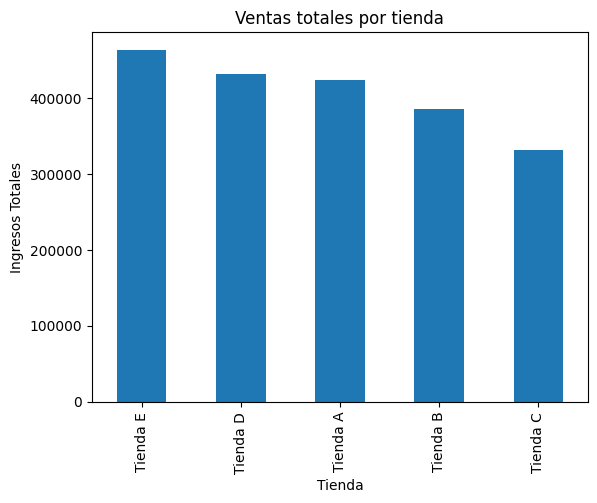

Tienda
Tienda E    463384.73
Tienda D    431107.13
Tienda A    424228.05
Tienda B    384941.41
Tienda C    331483.41
Name: Total, dtype: float64

In [25]:
# 2. Desempeño por tienda
ventas_por_tienda = df.groupby("Tienda")["Total"].sum()
ventas_por_tienda = ventas_por_tienda.sort_values(ascending=False)

ventas_por_tienda.plot(kind="bar")

plt.title("Ventas totales por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ingresos Totales")

plt.show()
ventas_por_tienda

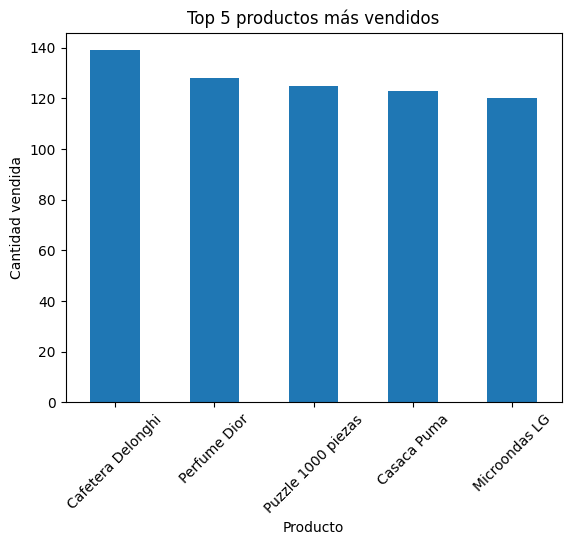

Producto
Cafetera Delonghi     139
Perfume Dior          128
Puzzle 1000 piezas    125
Casaca Puma           123
Microondas LG         120
Name: Cantidad, dtype: int64

In [12]:
# 3. Productos más vendidos (Top 5)
Productos_mas_vendidos = df.groupby("Producto")["Cantidad"].sum().sort_values(ascending=False).head(5)

Productos_mas_vendidos.plot(kind="bar")

plt.title("Top 5 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")

plt.xticks(rotation=45)

plt.show()
Productos_mas_vendidos


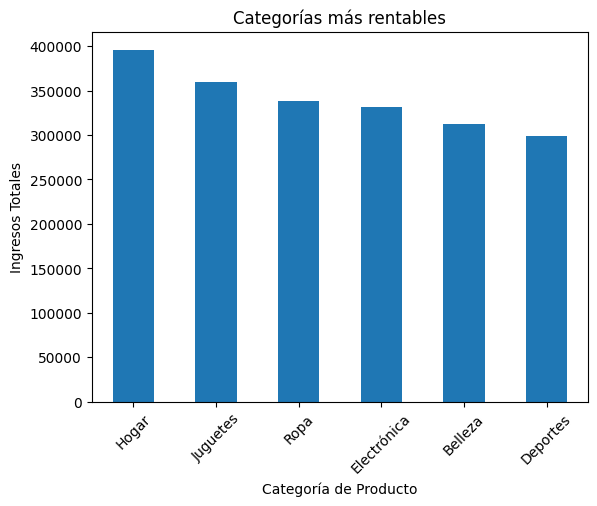

Categoria de Producto
Hogar          395862.04
Juguetes       359299.37
Ropa           337784.71
Electrónica    331688.48
Belleza        312072.66
Deportes       298437.47
Name: Total, dtype: float64

In [14]:
# 4. Categorías más rentables
Categoria_mas_rentable = df.groupby("Categoria de Producto")["Total"].sum().sort_values(ascending=False)

Categoria_mas_rentable.plot(kind="bar")

plt.title("Categorías más rentables")
plt.xlabel("Categoría de Producto")
plt.ylabel("Ingresos Totales")

plt.xticks(rotation=45)

plt.show()
Categoria_mas_rentable


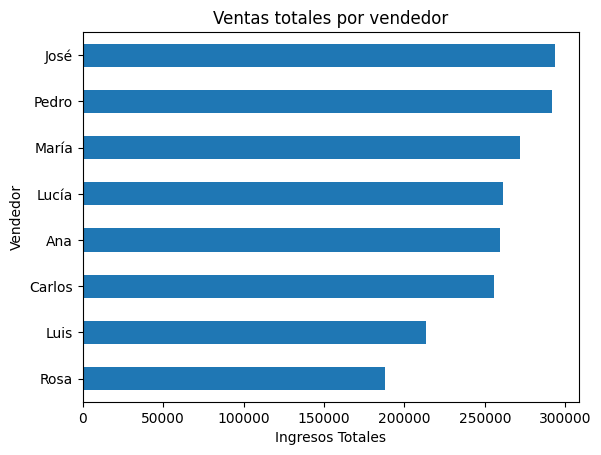

Vendedor
Rosa      188165.30
Luis      213368.30
Carlos    255771.37
Ana       259181.09
Lucía     261117.13
María     271861.99
Pedro     291807.96
José      293871.59
Name: Total, dtype: float64

In [18]:
# 5. Desempeño de vendedores
Desempeño_vendedor = df.groupby("Vendedor")["Total"].sum().sort_values(ascending=True)

Desempeño_vendedor.plot(kind="barh")

plt.title("Ventas totales por vendedor")
plt.xlabel("Ingresos Totales")
plt.ylabel("Vendedor")

plt.show()
Desempeño_vendedor

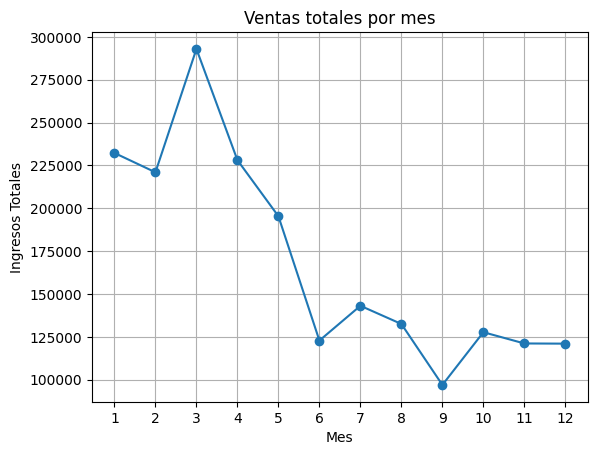

Mes
1     232293.16
2     221013.98
3     293002.56
4     228125.23
5     195372.89
6     122833.62
7     143129.23
8     132515.98
9      96956.75
10    127713.59
11    121148.36
12    121039.38
Name: Total, dtype: float64

In [19]:
# 6. Tendencia de ventas por mes
Ventas_por_mes = df.groupby("Mes")["Total"].sum().sort_index()

Ventas_por_mes.plot(kind="line", marker="o")

plt.title("Ventas totales por mes")
plt.xlabel("Mes")
plt.ylabel("Ingresos Totales")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()
Ventas_por_mes

In [20]:
# 7. Ticket promedio de venta
ticket_promedio = np.mean(df["Total"])

print(f"El ticket promedio de venta es: S/ {ticket_promedio:,.2f}")

El ticket promedio de venta es: S/ 4,070.29


In [21]:
# 8.Producto que genera más ingresos
ingresos_por_producto = df.groupby("Producto")["Total"].sum().sort_values(ascending=False)

producto_top = ingresos_por_producto.idxmax()
ingreso_top = ingresos_por_producto.max()

print(f"El producto que genera más ingresos es {producto_top} con S/ {ingreso_top:,.2f}")

El producto que genera más ingresos es Puzzle 1000 piezas con S/ 127,851.96


In [23]:
# 9. Relación entre cantidad vendida y ventas totales
relacion_ventas = df.groupby("Producto").agg({
    "Cantidad": "sum",
    "Total": "sum"
})
relacion_ventas

,Cantidad,Total
Producto,,
Auriculares Sony,64,63235.86
Auto Hot Wheels,66,41676.24
Balón Adidas,111,70883.58
Bicicleta Trek,99,71479.00
Cafetera Delonghi,139,88043.80
Camisa Lacoste,96,46003.48
Casaca Puma,123,98413.24
Crema Nivea,84,65094.67
Cuerda para saltar,91,70070.80


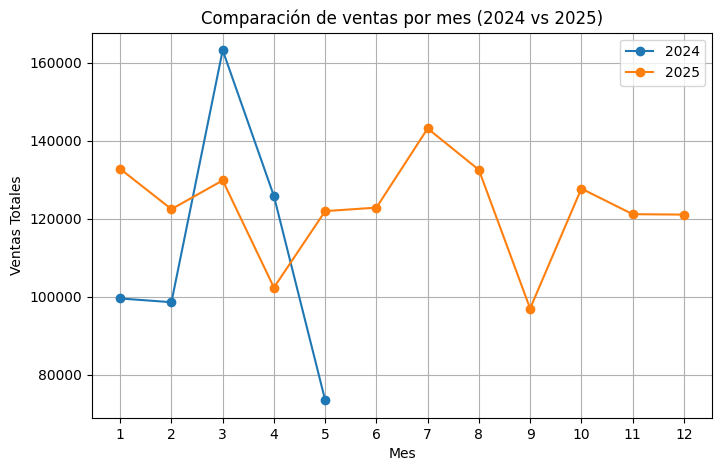

In [24]:
# 10.Comparación de ventas 2024 vs 2025
ventas_2024 = df[df["Año"] == 2024].groupby("Mes")["Total"].sum().sort_index()
ventas_2025 = df[df["Año"] == 2025].groupby("Mes")["Total"].sum().sort_index()
plt.figure(figsize=(8,5))

plt.plot(ventas_2024.index, ventas_2024.values, marker="o", label="2024")
plt.plot(ventas_2025.index, ventas_2025.values, marker="o", label="2025")

plt.title("Comparación de ventas por mes (2024 vs 2025)")
plt.xlabel("Mes")
plt.ylabel("Ventas Totales")

plt.xticks(range(1,13))
plt.legend()
plt.grid(True)

plt.show()